# LEAD Dataset
---
Explores the preprocessed downstream datasets used in the [LEAD EEG Foundation Model](https://github.com/DL4mHealth/LEAD) for Alzheimer's Disease detection.

Each dataset lives under `data/lead/<window_length>/<dataset_name>/` and contains:
- `meta.json` — shape metadata, sampling rates, channel count
- `X.dat` — EEG segments as float32 memmap, shape `[N, T, C]`
- `y.dat` — labels as float32 memmap, shape `[N, 3]`: `[label, subject_id, sampling_rate]`

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

LEAD_ROOT = "../data/lead"

## 1. Dataset Inventory

In [20]:
dataset_path

'../data/lead/L400/ADFTD-RS'

In [18]:
meta

{'N': 121825,
 'T': 400,
 'C': 19,
 'SAMPLE_RATE_LIST': [200, 100, 50],
 'OVERLAP': 200,
 'STEP': 200,
 'X_path': 'Processed\\L400\\ADFTD-RS\\X.dat',
 'y_path': 'Processed\\L400\\ADFTD-RS\\y.dat'}

In [16]:
print("y: ", y)
print("Shape of y: ", y.shape)
print("Every row is a segment with [class, subject, sampling_rate]")
print("Number of segments: ", y.shape[0])
print("Number of classes.    : ", len(np.unique(y[:, 0])))
print("Number of participants: ", len(np.unique(y[:, 1])))
print("Unique sampling rates in y: ", np.unique(y[:, 2]))
print("Segments per class: ", {k: np.sum(y[:, 0] == k) for k in np.unique(y[:, 0])})

y:  [[  1.   1. 200.]
 [  1.   1. 200.]
 [  1.   1. 200.]
 ...
 [  2.  88.  50.]
 [  2.  88.  50.]
 [  2.  88.  50.]]
Shape of y:  (121825, 3)
Every row is a segment with [class, subject, sampling_rate]
Number of segments:  121825
Number of classes.    :  3
Number of participants:  88
Unique sampling rates in y:  [ 50. 100. 200.]
Segments per class:  {0.0: 42067, 1.0: 50826, 2.0: 28932}


L is 400 (given by file name). sampling_rate given by y. 
L = sampling_rate x n_seconds_per_window

hz = 200:
400 = 200 x n -> n = 2

person 1:
number of windows = 598. 
total time = number_of_windows * n_seconds_per_window = 598 * 2 = 1196s = 19.933 min

person 2:
number of windows = 792
total time = 792 * 2 = 26.4 min



hz = 100
400 = 100 x n -> n = 4 sec/window

person 1:
number of windows = 298
total time = 298 * 4 = 1192s = 19.866 min

person 2:
number of windoes = 395
total time = 26.33 min


In [36]:
# all segments where y[0] == 1 and y[1] == 1
print("Segments with class 1 and subject 1 and sampling rate 200: ", len(y[(y[:, 0] == 1) & (y[:, 1] == 1) & (y[:, 2] == 200.0)]))
print("Segments with class 1 and subject 1 and sampling rate 100: " , len(y[(y[:, 0] == 1) & (y[:, 1] == 1) & (y[:, 2] == 100.0)]))
print("Segments with class 1 and subject 1 and sampling rate 50: "  , len(y[(y[:, 0] == 1) & (y[:, 1] == 1) & (y[:, 2] == 50.0)]))

print("\n")
print("Segments with class 1 and subject 2 and sampling rate 200: ", len(y[(y[:, 0] == 1) & (y[:, 1] == 2) & (y[:, 2] == 200.0)]))
print("Segments with class 1 and subject 2 and sampling rate 100: " , len(y[(y[:, 0] == 1) & (y[:, 1] == 2) & (y[:, 2] == 100.0)]))
print("Segments with class 1 and subject 2 and sampling rate 50: "  , len(y[(y[:, 0] == 1) & (y[:, 1] == 2) & (y[:, 2] == 50.0)]))

Segments with class 1 and subject 1 and sampling rate 200:  598
Segments with class 1 and subject 1 and sampling rate 100:  298
Segments with class 1 and subject 1 and sampling rate 50:  148


Segments with class 1 and subject 2 and sampling rate 200:  792
Segments with class 1 and subject 2 and sampling rate 100:  395
Segments with class 1 and subject 2 and sampling rate 50:  197


In [37]:
print(np.sum(y[:, 2] == 50.) / y.shape[0])

print(np.sum(y[:, 2] == 100) / y.shape[0])
print(np.sum(y[:, 2] == 200) / y.shape[0])

0.1422614405910117
0.2855571516519598
0.5721814077570285


In [62]:
np.unique(y[:, 1])

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.,
       27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38., 39.,
       40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51., 52.,
       53., 54., 55., 56., 57., 58., 59., 60., 61., 62., 63., 64., 65.,
       66., 67., 68., 69., 70., 71., 72., 73., 74., 75., 76., 77., 78.,
       79., 80., 81., 82., 83., 84., 85., 86., 87., 88.], dtype=float32)

In [ ]:
mask = y[:, 1] == 1
y[mask][:, 0]

array([  1.,   1., 200.], dtype=float32)

In [38]:
# Discover all splits and load their metadata + y.dat summaries
splits = []

for window_dir in sorted(os.listdir(LEAD_ROOT)):
    window_path = os.path.join(LEAD_ROOT, window_dir)
    if not os.path.isdir(window_path):
        continue
    
    for dataset_dir in sorted(os.listdir(window_path)):
        dataset_path = os.path.join(window_path, dataset_dir)
        meta_path = os.path.join(dataset_path, "meta.json")
        if not os.path.exists(meta_path):
            continue

        with open(meta_path) as f:
            meta = json.load(f)

        N, T, C = meta["N"], meta["T"], meta["C"]
        sr_list = meta["SAMPLE_RATE_LIST"]

        y = np.fromfile(os.path.join(dataset_path, "y.dat"), dtype=np.float32).reshape(N, 3)
        n_subjects  = len(np.unique(y[:, 1]))
        label_counts = {int(k): int(v) for k, v in zip(*np.unique(y[:, 0], return_counts=True))}
        n_classes   = len(label_counts)

        # y[:, 2] is usually stored as sampling-rate values (Hz), but some exports
        # may store sampling-rate ids. Support both.
        total_time_sec = 0.0
        total_times = []
        y_sr = y[:, 2]
        uses_ids = np.all(np.isin(np.unique(y_sr), np.arange(len(sr_list))))
        for sr_id, sr in enumerate(sr_list):
            if uses_ids:
                count = np.sum(np.isclose(y_sr, sr_id))
            else:
                count = np.sum(np.isclose(y_sr, sr))
            sr_time_sec = count * (T / sr)
            total_times.append(round(sr_time_sec, 1))
            total_time_sec += sr_time_sec

        splits.append({
            "Dataset":         dataset_dir,
            "Window (L)": T,
            "Channels (C)": C,
            "Segments (N)": N,
            "Subjects": n_subjects,
            "Classes": n_classes,
            "Sampling Rates (Hz)": str(sr_list),
            "Overlap": meta["OVERLAP"],
            "Step": meta["STEP"],
            "total_times": total_times,
            "total_time_total_min": round(total_time_sec / 60, 1),
            "_path": dataset_path,
            "_label_counts": label_counts,
            "_y": y,
        })

inv = pd.DataFrame(splits).drop(columns=["_path", "_label_counts", "_y"])
print("=== LEAD Downstream Datasets ===")
print(inv.to_string(index=False))

=== LEAD Downstream Datasets ===
 Dataset  Window (L)  Channels (C)  Segments (N)  Subjects  Classes Sampling Rates (Hz)  Overlap  Step                    total_times  total_time_total_min
   ADFSU         100            19          4048        92        2           [100, 50]       50    50               [2760.0, 2576.0]                  88.9
    ADSZ         100            19          1128        48        2           [100, 50]       50    50                 [768.0, 720.0]                  24.8
   APAVA         200            16          9282        23        2      [200, 100, 50]      100   100       [5967.0, 5304.0, 2652.0]                 232.0
   ADFTD         400            19        167083        88        3      [200, 100, 50]      200   200 [191324.0, 190796.0, 189776.0]                9531.6
ADFTD-PS         400            19         45258        88        3      [200, 100, 50]      200   200    [51912.0, 51644.0, 51128.0]                2578.1
ADFTD-RS         400           

## 2. Window & Sampling Rate Design

LEAD uses a **multi-sampling segmentation** strategy: each recording is downsampled to multiple rates and segmented into fixed-length windows. A window of L timestamps corresponds to:

| L   | @ 200 Hz | @ 100 Hz | @ 50 Hz |
|-----|----------|----------|---------|
| 100 | 0.5 s    | 1 s      | 2 s     |
| 200 | 1 s      | 2 s      | 4 s     |
| 400 | 2 s      | 4 s      | 8 s     |

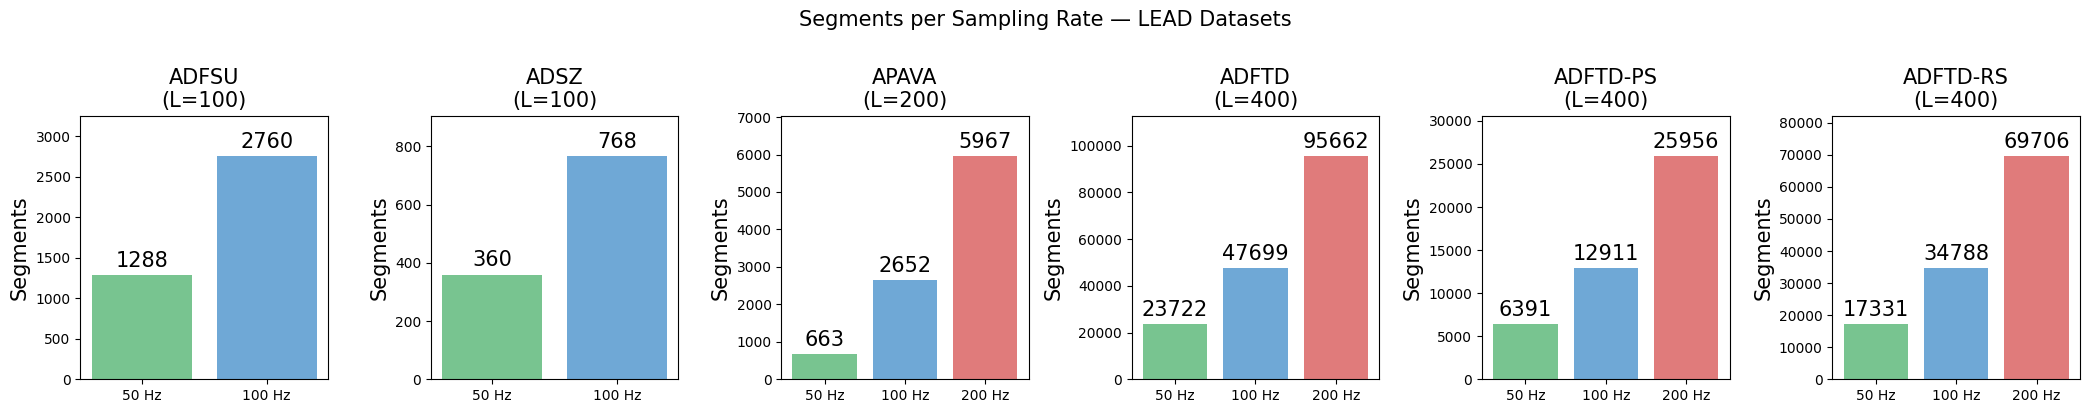

In [42]:
# Sampling rate distribution per dataset
fig, axes = plt.subplots(1, len(splits), figsize=(3.5 * len(splits), 4), sharey=False)
if len(splits) == 1:
    axes = [axes]

sr_palette = {50: "#78C490", 100: "#6FA8D6", 200: "#E07B7B"}

for ax, s in zip(axes, splits):
    y = s["_y"]
    srs, counts = np.unique(y[:, 2], return_counts=True)
    bars = ax.bar([f"{int(sr)} Hz" for sr in srs], counts,
                  color=[sr_palette.get(int(sr), "#CCCCCC") for sr in srs])
    ax.bar_label(bars, padding=3, fontsize=15)
    ax.set_title(f"{s['Dataset']}\n(L={s['Window (L)']})", fontsize=15)
    ax.set_ylabel("Segments", fontsize=15)
    ax.set_ylim(0, counts.max() * 1.18)

plt.suptitle("Segments per Sampling Rate — LEAD Datasets", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 3. Class Distribution

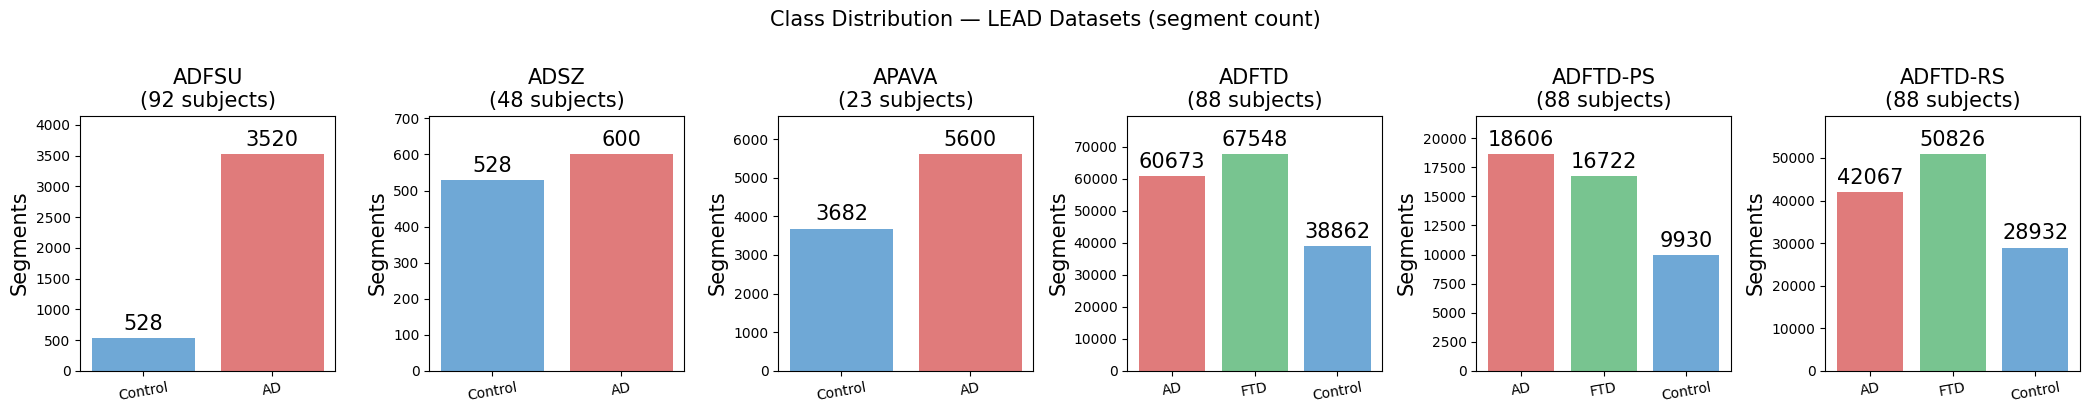

In [43]:
# For datasets with known class mappings
# Binary datasets (ADFSU, ADSZ, APAVA, BACA-RS): 0 = Control, 1 = AD
# 3-class datasets (ADFTD): 0 = AD, 1 = FTD, 2 = Control
label_maps = {
    2: {0: "Control", 1: "AD"},
    3: {0: "AD", 1: "FTD", 2: "Control"},
}
class_colors = {
    "Control": "#6FA8D6",
    "AD":      "#E07B7B",
    "FTD":     "#78C490",
}

fig, axes = plt.subplots(1, len(splits), figsize=(3.5 * len(splits), 4), sharey=False)
if len(splits) == 1:
    axes = [axes]

for ax, s in zip(axes, splits):
    lc = s["_label_counts"]
    lmap = label_maps.get(len(lc), {k: str(k) for k in lc})
    labels = [lmap[k] for k in sorted(lc)]
    counts = [lc[k] for k in sorted(lc)]
    colors = [class_colors.get(l, "#CCCCCC") for l in labels]
    bars = ax.bar(labels, counts, color=colors)
    ax.bar_label(bars, padding=3, fontsize=15)
    ax.set_title(f"{s['Dataset']}\n({s['Subjects']} subjects)", fontsize=15)
    ax.set_ylabel("Segments", fontsize=15)
    ax.set_ylim(0, max(counts) * 1.18)
    ax.tick_params(axis="x", rotation=10)

plt.suptitle("Class Distribution — LEAD Datasets (segment count)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 4. Subject Counts per Dataset

In [44]:
# Segments per subject (load balancing)
for s in splits:
    y = s["_y"]
    lmap = label_maps.get(s["Classes"], {k: str(k) for k in s["_label_counts"]})
    print(f"\n{'─'*50}")
    print(f"Dataset: {s['Dataset']}  (L={s['Window (L)']}, C={s['Channels (C)']} channels)")
    print(f"  Total segments : {s['Segments (N)']:,}")
    print(f"  Total subjects : {s['Subjects']}")
    print(f"  Avg segs/subj  : {s['Segments (N)'] / s['Subjects']:.0f}")
    # per-class subject count
    for label_id in sorted(s["_label_counts"]):
        mask = y[:, 0] == label_id
        n_sub = len(np.unique(y[mask, 1]))
        n_seg = mask.sum()
        print(f"  [{lmap[label_id]}] {n_sub} subjects, {n_seg:,} segments, {n_seg/n_sub:.0f} segs/subj")


──────────────────────────────────────────────────
Dataset: ADFSU  (L=100, C=19 channels)
  Total segments : 4,048
  Total subjects : 92
  Avg segs/subj  : 44
  [Control] 12 subjects, 528 segments, 44 segs/subj
  [AD] 80 subjects, 3,520 segments, 44 segs/subj

──────────────────────────────────────────────────
Dataset: ADSZ  (L=100, C=19 channels)
  Total segments : 1,128
  Total subjects : 48
  Avg segs/subj  : 24
  [Control] 24 subjects, 528 segments, 22 segs/subj
  [AD] 24 subjects, 600 segments, 25 segs/subj

──────────────────────────────────────────────────
Dataset: APAVA  (L=200, C=16 channels)
  Total segments : 9,282
  Total subjects : 23
  Avg segs/subj  : 404
  [Control] 11 subjects, 3,682 segments, 335 segs/subj
  [AD] 12 subjects, 5,600 segments, 467 segs/subj

──────────────────────────────────────────────────
Dataset: ADFTD  (L=400, C=19 channels)
  Total segments : 167,083
  Total subjects : 88
  Avg segs/subj  : 1899
  [AD] 29 subjects, 60,673 segments, 2092 segs/subj

## 5. Signal Peek — One Segment per Class

In [45]:
# Pick a dataset to visualize — ADFTD-RS is richest (3-class)
viz_split = next(s for s in splits if s["Dataset"] == "ADFTD-RS")

N, T, C = viz_split["Segments (N)"], viz_split["Window (L)"], viz_split["Channels (C)"]
print(f"Loading X.dat for {viz_split['Dataset']}: {N:,} × {T} × {C}  (this may take a moment)")

X = np.memmap(os.path.join(viz_split["_path"], "X.dat"), dtype=np.float32, mode="r").reshape(N, T, C)
y = viz_split["_y"]
print("Done.")

Loading X.dat for ADFTD-RS: 121,825 × 400 × 19  (this may take a moment)


FileNotFoundError: [Errno 2] No such file or directory: '../data/lead/L400/ADFTD-RS/X.dat'

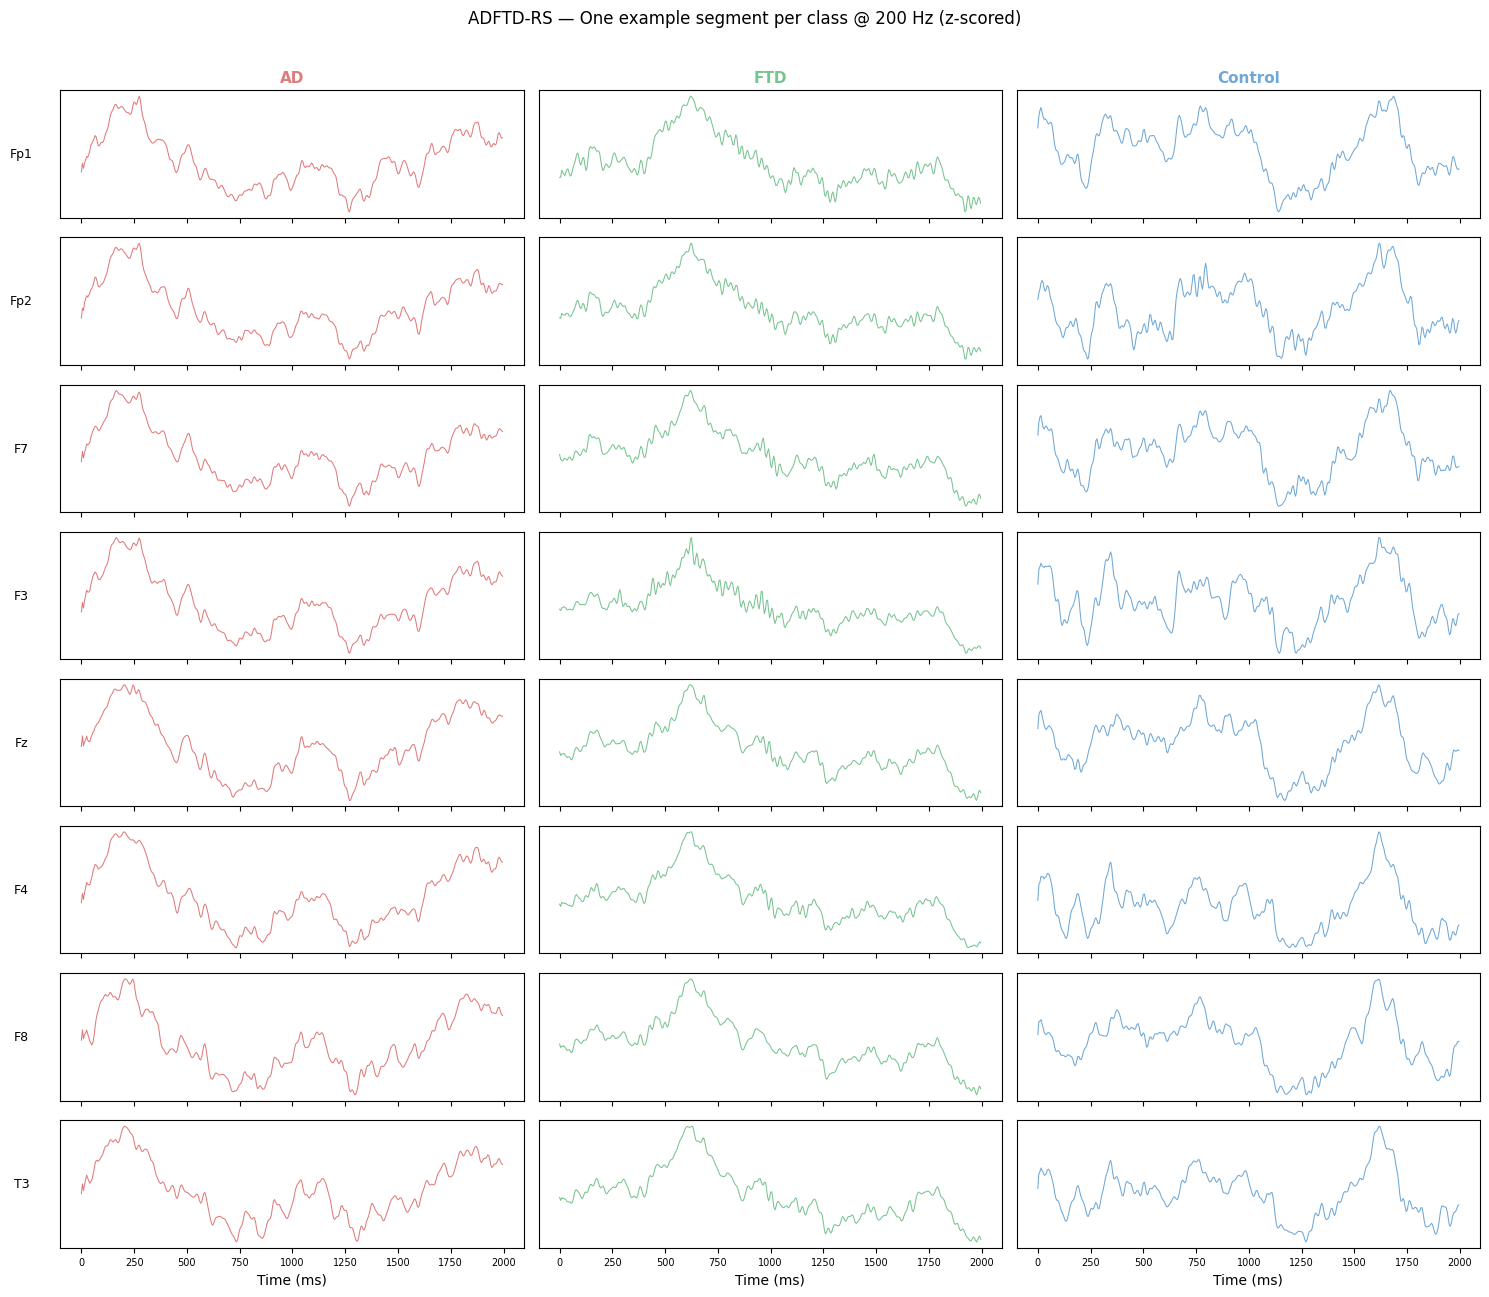

In [7]:
# Standard 19-channel 10-20 names (LEAD channel order from README)
CH_NAMES = ["Fp1","Fp2","F7","F3","Fz","F4","F8",
            "T3","C3","Cz","C4","T4",
            "T5","P3","Pz","P4","T6",
            "O1","O2"]

lmap = label_maps[3]  # ADFTD is 3-class
N_SHOW_CH = 8         # channels to plot

# Use a 200 Hz segment so time axis is clean
mask_200 = y[:, 2] == 200.0
y_200 = y[mask_200]
idx_200 = np.where(mask_200)[0]

unique_labels = sorted(np.unique(y_200[:, 0]).astype(int).tolist())
time_ms = np.arange(T) / 200 * 1000  # ms at 200 Hz

fig, axes = plt.subplots(N_SHOW_CH, len(unique_labels),
                          figsize=(5 * len(unique_labels), 1.6 * N_SHOW_CH),
                          sharex=True)

palette = {0: "#E07B7B", 1: "#78C490", 2: "#6FA8D6"}

for col, label in enumerate(unique_labels):
    # pick first segment with this label at 200 Hz
    local_idx = np.where(y_200[:, 0] == label)[0][0]
    global_idx = idx_200[local_idx]
    segment = X[global_idx]  # (T, C)
    
    # z-score normalize per channel (as LEAD does at load time)
    mu = segment.mean(axis=0, keepdims=True)
    sd = segment.std(axis=0, keepdims=True) + 1e-8
    segment_z = (segment - mu) / sd

    for row in range(N_SHOW_CH):
        ax = axes[row, col]
        ax.plot(time_ms, segment_z[:, row], linewidth=0.75, color=palette[label])
        if col == 0:
            ch = CH_NAMES[row] if row < len(CH_NAMES) else f"CH{row}"
            ax.set_ylabel(ch, fontsize=9, rotation=0, labelpad=28, va="center")
        if row == 0:
            ax.set_title(lmap[label], fontsize=11, fontweight="bold", color=palette[label])
        if row == N_SHOW_CH - 1:
            ax.set_xlabel("Time (ms)")
        ax.tick_params(labelsize=7)
        ax.set_yticks([])

plt.suptitle(f"ADFTD-RS — One example segment per class @ 200 Hz (z-scored)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 6. Signal Statistics per Class

In [8]:
# Raw amplitude stats (before z-score) for a sample of segments
SAMPLE = 500  # segments per class

print(f"Raw amplitude statistics (sample of {SAMPLE} segments per class, ADFTD-RS)\n")
rows = []
for label in unique_labels:
    idxs = np.where(y[:, 0] == label)[0]
    chosen = np.random.default_rng(42).choice(idxs, size=min(SAMPLE, len(idxs)), replace=False)
    segs = X[chosen]  # (SAMPLE, T, C)
    rows.append({
        "Class": lmap[label],
        "Mean (µV)": f"{segs.mean():.4f}",
        "Std (µV)": f"{segs.std():.4f}",
        "Min (µV)": f"{segs.min():.4f}",
        "Max (µV)": f"{segs.max():.4f}",
        "P5 (µV)": f"{np.percentile(segs, 5):.4f}",
        "P95 (µV)": f"{np.percentile(segs, 95):.4f}",
    })

print(pd.DataFrame(rows).to_string(index=False))

Raw amplitude statistics (sample of 500 segments per class, ADFTD-RS)

  Class Mean (µV) Std (µV) Min (µV) Max (µV) P5 (µV) P95 (µV)
     AD   -0.0000   0.0000  -0.0006   0.0005 -0.0001   0.0001
    FTD    0.0000   0.0000  -0.0004   0.0007 -0.0001   0.0001
Control    0.0000   0.0000  -0.0004   0.0004 -0.0001   0.0001


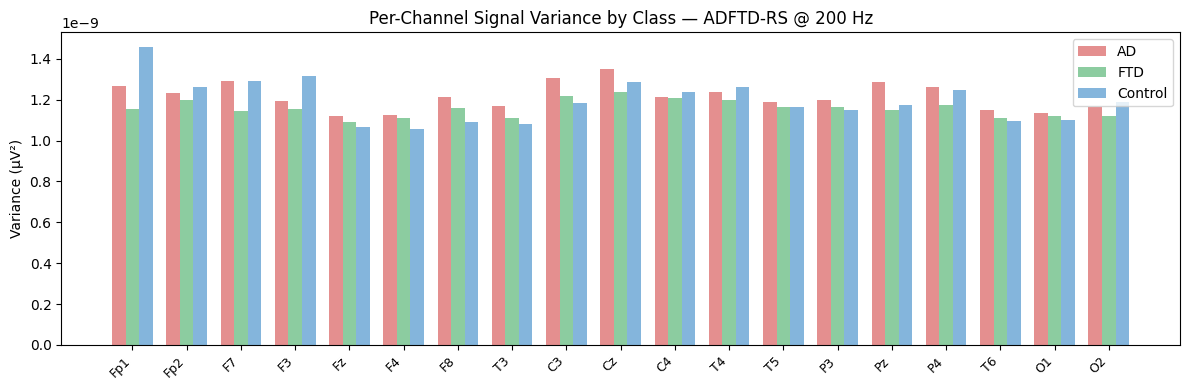

In [9]:
# Per-channel mean power (variance) by class — ADFTD-RS @ 200 Hz sample
fig, ax = plt.subplots(figsize=(12, 4))

ch_indices = np.arange(C)
width = 0.25

for i, label in enumerate(unique_labels):
    idxs = np.where((y[:, 0] == label) & (y[:, 2] == 200.0))[0]
    chosen = np.random.default_rng(42).choice(idxs, size=min(300, len(idxs)), replace=False)
    segs = X[chosen]  # (n, T, C)
    channel_var = segs.var(axis=(0, 1))  # variance per channel
    ax.bar(ch_indices + i * width, channel_var, width, label=lmap[label], color=palette[label], alpha=0.85)

ax.set_xticks(ch_indices + width)
ax.set_xticklabels(CH_NAMES[:C], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Variance (µV²)")
ax.set_title("Per-Channel Signal Variance by Class — ADFTD-RS @ 200 Hz")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

| Dataset | Task | Window | Channels | Subjects | Segments | Sampling Rates |
|---------|------|--------|----------|----------|----------|-----------------|
| ADFSU   | AD vs Control (binary) | L100 | 19 | 92 | 4,048 | 50, 100 Hz |
| ADSZ    | AD vs Control (binary) | L100 | 19 | 48 | 1,128 | 50, 100 Hz |
| APAVA   | AD vs Control (binary) | L200 | 16 | 23 | 9,282 | 50, 100, 200 Hz |
| ADFTD-RS | AD / FTD / Control (3-class, resting) | L400 | 19 | 88 | 121,825 | 50, 100, 200 Hz |
| ADFTD-PS | AD / FTD / Control (3-class, passive) | L400 | 19 | 88 | 45,258 | 50, 100, 200 Hz |
| ADFTD   | AD / FTD / Control (3-class, combined) | L400 | 19 | 88 | 167,083 | 50, 100, 200 Hz |

**y.dat columns:** `[label, subject_id, sampling_rate]` — dtype float32, shape `[N, 3]`  
**X.dat shape:** `[N, T, C]` — dtype float32, z-score normalized per channel at load time

## 7. APAVA Deep Dive

In [48]:
for sr, cnt in zip(*np.unique(y_apava[:,2], return_counts=True)):
    print(f"Sampling rate {sr} Hz: {cnt} segments")

Sampling rate 50.0 Hz: 663 segments
Sampling rate 100.0 Hz: 2652 segments
Sampling rate 200.0 Hz: 5967 segments


In [46]:
# Load APAVA metadata and data
apava_path = os.path.join(LEAD_ROOT, "L200", "APAVA")
with open(os.path.join(apava_path, "meta.json")) as f:
    apava_meta = json.load(f)

N, T, C = apava_meta["N"], apava_meta["T"], apava_meta["C"]
print(f"meta: {apava_meta}")
print(f"\nX shape: [{N}, {T}, {C}]  → {N} segments × {T} timepoints × {C} channels")

X_apava = np.fromfile(os.path.join(apava_path, "X.dat"), dtype=np.float32).reshape(N, T, C)
y_apava = np.fromfile(os.path.join(apava_path, "y.dat"), dtype=np.float32).reshape(N, 3)

print(f"\ny shape: {y_apava.shape}")
print(f"Labels (y[:,0]):       {np.unique(y_apava[:,0])}  → 0=Control, 1=AD")
print(f"Subjects (y[:,1]):     {len(np.unique(y_apava[:,1]))} unique subjects")
print(f"Sampling rates (y[:,2]): {np.unique(y_apava[:,2])} Hz")

# Segments per sampling rate
print("\nSegments per sampling rate:")
for sr, cnt in zip(*np.unique(y_apava[:,2], return_counts=True)):
    window_sec = T / sr
    step_sec = apava_meta["STEP"] / sr
    print(f"  {int(sr):3d} Hz: {cnt:5d} segments  (window={window_sec:.1f}s, step={step_sec:.1f}s)")

# Segments per class per sampling rate
print("\nSegments per class × sampling rate:")
for sr in np.unique(y_apava[:,2]):
    for lbl, name in [(0, "Control"), (1, "AD")]:
        cnt = np.sum((y_apava[:,0]==lbl) & (y_apava[:,2]==sr))
        print(f"  {int(sr)} Hz, {name}: {cnt}")

# Raw amplitude stats
print(f"\nX stats: mean={X_apava.mean():.6f}, std={X_apava.std():.6f}, min={X_apava.min():.6f}, max={X_apava.max():.6f}")


meta: {'N': 9282, 'T': 200, 'C': 16, 'SAMPLE_RATE_LIST': [200, 100, 50], 'OVERLAP': 100, 'STEP': 100, 'X_path': 'Processed\\L200\\APAVA\\X.dat', 'y_path': 'Processed\\L200\\APAVA\\y.dat'}

X shape: [9282, 200, 16]  → 9282 segments × 200 timepoints × 16 channels

y shape: (9282, 3)
Labels (y[:,0]):       [0. 1.]  → 0=Control, 1=AD
Subjects (y[:,1]):     23 unique subjects
Sampling rates (y[:,2]): [ 50. 100. 200.] Hz

Segments per sampling rate:
   50 Hz:   663 segments  (window=4.0s, step=2.0s)
  100 Hz:  2652 segments  (window=2.0s, step=1.0s)
  200 Hz:  5967 segments  (window=1.0s, step=0.5s)

Segments per class × sampling rate:
  50 Hz, Control: 263
  50 Hz, AD: 400
  100 Hz, Control: 1052
  100 Hz, AD: 1600
  200 Hz, Control: 2367
  200 Hz, AD: 3600

X stats: mean=0.000000, std=78.083160, min=-1014.655640, max=5641.846191


In [49]:
X_apava.shape

(9282, 200, 16)

In [54]:
X_apava[0]

array([[ 115.49553  ,   42.43145  ,   66.37516  , ...,    2.8419733,
        -126.3771   , -245.60088  ],
       [ 115.81017  ,   37.74494  ,   64.346596 , ...,   -6.483398 ,
        -123.87055  , -248.42966  ],
       [ 117.91758  ,   39.872414 ,   69.18911  , ...,   -0.5208486,
        -133.3999   , -243.93134  ],
       ...,
       [ 114.55421  ,   43.90346  ,   64.88321  , ...,   21.211672 ,
        -146.43883  , -251.00722  ],
       [ 116.17072  ,   45.087345 ,   65.68413  , ...,   13.946647 ,
        -150.13403  , -250.50536  ],
       [ 119.34559  ,   48.741776 ,   68.83633  , ...,   10.916589 ,
        -153.05681  , -246.07411  ]], dtype=float32)

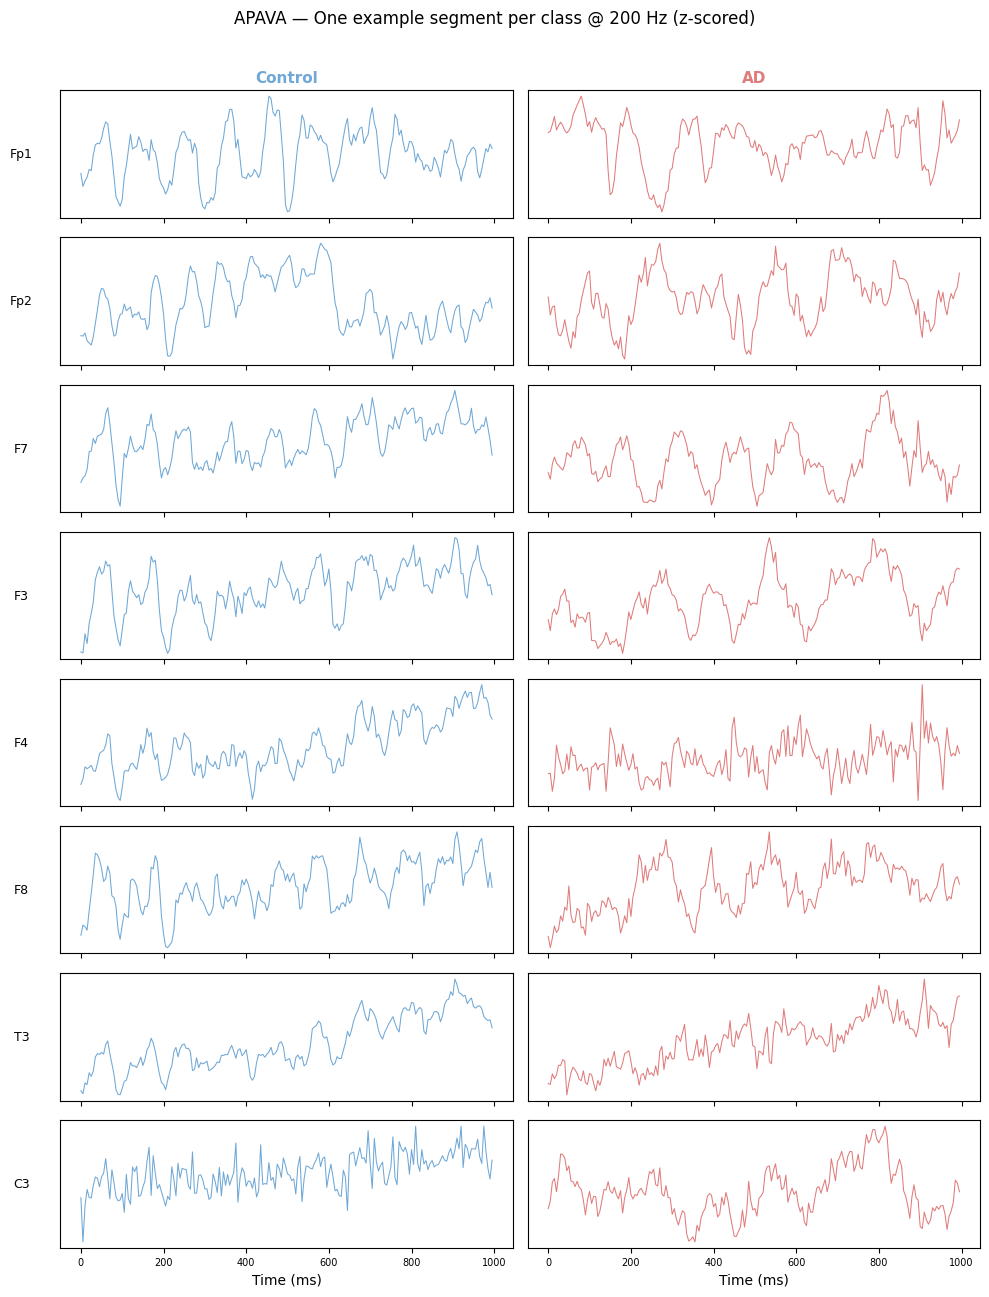

In [74]:
# APAVA channel names (16-channel subset of 10-20 system)
APAVA_CH_NAMES = ["Fp1","Fp2","F7","F3","F4","F8",
                  "T3","C3","C4","T4",
                  "T5","P3","P4","T6",
                  "O1","O2"]

lmap_bin = {0: "Control", 1: "AD"}
palette_bin = {0: "#6FA8D6", 1: "#E07B7B"}
N_SHOW_CH = 8

# Use 200 Hz segments for clean time axis
mask_200 = y_apava[:, 2] == 200.0
y_200 = y_apava[mask_200]
idx_200 = np.where(mask_200)[0]
unique_labels = sorted(np.unique(y_200[:, 0]).astype(int).tolist())
time_ms = np.arange(T) / 200 * 1000  # ms at 200 Hz

fig, axes = plt.subplots(N_SHOW_CH, len(unique_labels),
                          figsize=(5 * len(unique_labels), 1.6 * N_SHOW_CH),
                          sharex=True)

for col, label in enumerate(unique_labels):
    local_idx = np.where(y_200[:, 0] == label)[0][0]
    global_idx = idx_200[local_idx]
    segment = X_apava[global_idx]  # (T, C)
    mu = segment.mean(axis=0, keepdims=True)
    sd = segment.std(axis=0, keepdims=True) + 1e-8
    segment_z = (segment - mu) / sd

    for row in range(N_SHOW_CH):
        ax = axes[row, col]
        ax.plot(time_ms, segment_z[:, row], linewidth=0.75, color=palette_bin[label])
        if col == 0:
            ax.set_ylabel(APAVA_CH_NAMES[row], fontsize=9, rotation=0, labelpad=28, va="center")
        if row == 0:
            ax.set_title(lmap_bin[label], fontsize=11, fontweight="bold", color=palette_bin[label])
        if row == N_SHOW_CH - 1:
            ax.set_xlabel("Time (ms)")
        ax.tick_params(labelsize=7)
        ax.set_yticks([])

plt.suptitle("APAVA — One example segment per class @ 200 Hz (z-scored)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


In [117]:
import sys, importlib
sys.path.insert(0, "..")
from src import extract_biomarkers
importlib.reload(extract_biomarkers)
from src.extract_biomarkers import compute_band_powers

# Pick one APAVA segment: first Control @ 200 Hz
sr = 200.0
lbl = 0  # Control
idx = np.where((y_apava[:, 0] == lbl) & (y_apava[:, 2] == sr))[0][0]
segment = X_apava[idx]  # (T=200, C=16)

# Wrap into MNE RawArray — shape must be (n_channels, n_times)
info = mne.create_info(ch_names=APAVA_CH_NAMES, sfreq=sr, ch_types="eeg")
raw = mne.io.RawArray(segment.T, info, verbose=False)  # (16, 200)

band_powers, freqs, psd_array = compute_band_powers(raw)

print(f"Segment index: {idx}  |  class=Control  |  sr={int(sr)} Hz  |  shape={segment.shape}")
print(f"Relative band powers (mean across {C} channels):")
for band, power in band_powers.items():
    print(f"  {band:6s}: {power:.4f}")


<class 'numpy.ndarray'> (101,)
<class 'numpy.ndarray'> (101,)
<class 'numpy.ndarray'> (101,)
<class 'numpy.ndarray'> (101,)
<class 'numpy.ndarray'> (101,)
<class 'numpy.ndarray'> (101,)
<class 'numpy.ndarray'> (101,)
<class 'numpy.ndarray'> (101,)
<class 'numpy.ndarray'> (101,)
<class 'numpy.ndarray'> (101,)
<class 'numpy.ndarray'> (101,)
<class 'numpy.ndarray'> (101,)
<class 'numpy.ndarray'> (101,)
<class 'numpy.ndarray'> (101,)
<class 'numpy.ndarray'> (101,)
<class 'numpy.ndarray'> (101,)
total power shape: (16,) [ 18.64597769  27.43295699  18.30956955  16.84320251  20.93016092
  14.00026496  27.18569004  18.99727882  24.49361264  69.48673824
  14.6067319   31.49167032   8.46873744  17.26699166   9.57598665
 122.76740203]
(101,) 4 [1. 2. 3. 4.]
delta power shape: (16,) [ 1.51677366 17.25018254  5.36832286  4.49221398 10.74592446  3.02433074
 16.03220691  5.80031709  2.56646765  4.45058004  1.91896792  2.19779883
  1.58675112  1.44806309  1.05522285 81.81625457]
total power shape: (16

In [81]:
import sys
sys.path.insert(0, "..")
import mne
from src.extract_biomarkers import compute_band_powers

# Pick one APAVA segment: first Control @ 200 Hz
sr = 200.0
lbl = 0  # Control
idx = np.where((y_apava[:, 0] == lbl) & (y_apava[:, 2] == sr))[0][0]
segment = X_apava[idx]  # (T=200, C=16)

# Wrap into MNE RawArray — shape must be (n_channels, n_times)
info = mne.create_info(ch_names=APAVA_CH_NAMES, sfreq=sr, ch_types="eeg")
raw = mne.io.RawArray(segment.T, info, verbose=False)  # (16, 200)

band_powers, freqs, psd_array = compute_band_powers(raw)

print(f"Segment index: {idx}  |  class=Control  |  sr={int(sr)} Hz  |  shape={segment.shape}")
print(f"Relative band powers (mean across {C} channels):")
for band, power in band_powers.items():
    print(f"  {band:6s}: {power:.4f}")


Segment index: 490  |  class=Control  |  sr=200 Hz  |  shape=(200, 16)
Relative band powers (mean across 16 channels):
  delta : 0.2695
  theta : 0.0765
  alpha : 0.5070
  beta  : 0.1682
  gamma : 0.0477
